# Exploratory Data Analysis: Detroit Dataset

This notebook presents an exploratory data analysis (EDA) of the Detroit dataset, a small annual time-series dataset commonly used for studying social and economic patterns related to homicide rates.

The data contain **13 yearly observations (1961-1973)** and 14 numeric variables: FTP, UEMP, MAN, LIC, GR, CLEAR, WM, NMAN, GOV, HE, WE, HOM, ACC, ASR.

The dependent (target) variable is **HOM**: homicide rate per 100,000 population.

## 2. Load Libraries and Dataset
We import core libraries for data handling and visualization, then load the dataset and preview the first rows to verify structure and content.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("detroit_dataset.csv")
df.head(15)

,FTP,UEMP,MAN,LIC,GR,CLEAR,WM,NMAN,GOV,HE,WE,HOM,ACC,ASR
0,260.35,11.0,455.5,178.15,215.98,93.4,558724,538.1,133.9,2.98,117.18,8.60,39.17,306.18
1,269.80,7.0,480.2,156.41,180.48,88.5,538584,547.6,137.6,3.09,134.02,8.90,40.27,315.16
2,272.04,5.2,506.1,198.02,209.57,94.4,519171,562.8,143.6,3.23,141.68,8.52,45.31,277.53
3,272.96,4.3,535.8,222.10,231.67,92.0,500457,591.0,150.3,3.33,147.98,8.89,49.51,234.07
4,272.51,3.5,576.0,301.92,297.65,91.0,482418,626.1,164.3,3.46,159.85,13.07,55.05,230.84
5,261.34,3.2,601.7,391.22,367.62,87.4,465029,659.8,179.5,3.60,157.19,14.57,53.90,217.99
6,268.89,4.1,577.3,665.56,616.54,88.3,448267,686.2,187.5,3.73,155.29,21.36,50.62,286.11
7,295.99,3.9,596.9,1131.21,1029.75,86.1,432109,699.6,195.4,2.91,131.75,28.03,51.47,291.59
8,319.87,3.6,613.5,837.60,786.23,79.0,416533,729.9,210.3,4.25,178.74,31.49,49.16,320.39
9,341.43,7.1,569.3,794.90,713.77,73.9,401518,757.8,223.8,4.47,178.30,37.39,45.80,323.03


**Interpretation:** The preview confirms the dataset loaded correctly and provides an initial view of variable ranges and formatting.

## 3. Dataset Overview
We inspect dimensions, column names, and data types to confirm the structural properties of the dataset. Each row should represent one year.

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (13, 14)

Columns:
['FTP', 'UEMP', 'MAN', 'LIC', 'GR', 'CLEAR', 'WM', 'NMAN', 'GOV', 'HE', 'WE', 'HOM', 'ACC', 'ASR']

Data types:
FTP      float64
UEMP     float64
MAN      float64
LIC      float64
GR       float64
CLEAR    float64
WM         int64
NMAN     float64
GOV      float64
HE       float64
WE       float64
HOM      float64
ACC      float64
ASR      float64
dtype: object


**Interpretation:** The output should confirm 13 observations and numeric columns, consistent with annual records from 1961 to 1973 (one row per year).

## 4. Data Quality Check
Before analysis, we check for missing values, duplicate rows, and whether all fields are numeric.

In [3]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()
numeric_check = df.apply(lambda s: pd.api.types.is_numeric_dtype(s)).all()

print("Missing values per column:")
print(missing)
print("\nNumber of duplicate rows:", duplicates)
print("All columns numeric:", numeric_check)

Missing values per column:
FTP      0
UEMP     0
MAN      0
LIC      0
GR       0
CLEAR    0
WM       0
NMAN     0
GOV      0
HE       0
WE       0
HOM      0
ACC      0
ASR      0
dtype: int64

Number of duplicate rows: 0
All columns numeric: True


**Interpretation:** If missing and duplicate counts are zero and numeric check is true, the dataset is clean and ready for direct EDA.

## 5. Descriptive Statistics
We summarize central tendency and spread for each variable using `describe()` to understand scale and variability.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FTP,13.0,304.511538,46.811656,260.35,269.80,272.96,341.43,390.19
UEMP,13.0,5.792308,2.359188,3.20,3.90,5.20,7.10,11.00
MAN,13.0,556.446154,49.822161,455.50,535.80,569.30,596.90,613.50
LIC,13.0,537.506923,316.415140,156.41,222.10,583.17,794.90,1131.21
GR,13.0,545.659231,311.031612,180.48,231.67,616.54,750.43,1029.75
CLEAR,13.0,81.446154,12.659227,58.90,73.90,87.40,91.00,94.40
WM,13.0,452507.538462,64568.123896,359647.00,401518.00,448267.00,500457.00,558724.00
NMAN,13.0,673.923077,94.773398,538.10,591.00,686.20,755.30,819.80
GOV,13.0,185.769231,37.036185,133.90,150.30,187.50,223.80,230.90
HE,13.0,3.947692,0.966559,2.91,3.23,3.60,4.47,5.76


**Interpretation:** Variables are measured on different scales (for example, rates vs counts/index-like measures), so comparisons should account for scale differences.

## 6. Add Year Column
Because observations are annual, we explicitly add a `Year` variable from 1961 to 1973 for time-based analysis and plotting.

In [5]:
df = df.copy()
df["Year"] = np.arange(1961, 1974)
df.head()

,FTP,UEMP,MAN,LIC,GR,CLEAR,WM,NMAN,GOV,HE,WE,HOM,ACC,ASR,Year
0,260.35,11.0,455.5,178.15,215.98,93.4,558724,538.1,133.9,2.98,117.18,8.60,39.17,306.18,1961
1,269.80,7.0,480.2,156.41,180.48,88.5,538584,547.6,137.6,3.09,134.02,8.90,40.27,315.16,1962
2,272.04,5.2,506.1,198.02,209.57,94.4,519171,562.8,143.6,3.23,141.68,8.52,45.31,277.53,1963
3,272.96,4.3,535.8,222.10,231.67,92.0,500457,591.0,150.3,3.33,147.98,8.89,49.51,234.07,1964
4,272.51,3.5,576.0,301.92,297.65,91.0,482418,626.1,164.3,3.46,159.85,13.07,55.05,230.84,1965


**Interpretation:** The `Year` column enables chronological visualizations and helps interpret structural trends over time.

## 7. Time Trend Analysis
We plot key variables across years to inspect long-run movement in homicide, arrest/clearance outcomes, labor structure, and firearm-related variables.

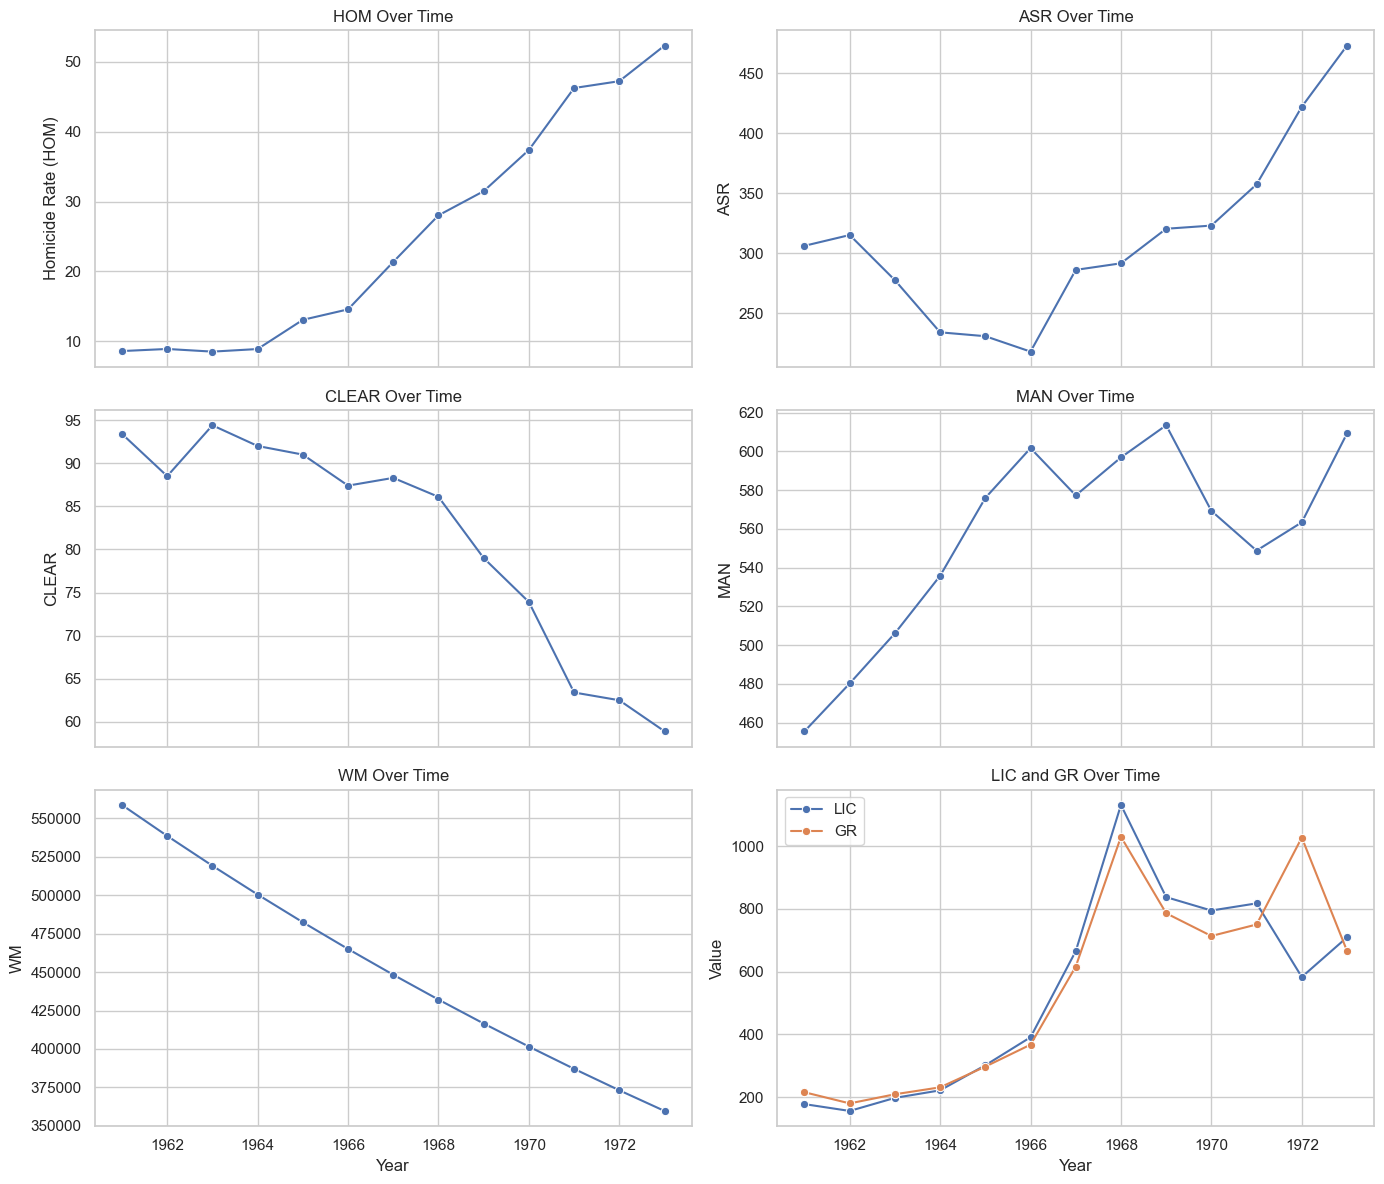

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

sns.lineplot(data=df, x="Year", y="HOM", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("HOM Over Time")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Homicide Rate (HOM)")

sns.lineplot(data=df, x="Year", y="ASR", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("ASR Over Time")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("ASR")

sns.lineplot(data=df, x="Year", y="CLEAR", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("CLEAR Over Time")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("CLEAR")

sns.lineplot(data=df, x="Year", y="MAN", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("MAN Over Time")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("MAN")

sns.lineplot(data=df, x="Year", y="WM", marker="o", ax=axes[2, 0])
axes[2, 0].set_title("WM Over Time")
axes[2, 0].set_xlabel("Year")
axes[2, 0].set_ylabel("WM")

sns.lineplot(data=df, x="Year", y="LIC", marker="o", label="LIC", ax=axes[2, 1])
sns.lineplot(data=df, x="Year", y="GR", marker="o", label="GR", ax=axes[2, 1])
axes[2, 1].set_title("LIC and GR Over Time")
axes[2, 1].set_xlabel("Year")
axes[2, 1].set_ylabel("Value")
axes[2, 1].legend()

plt.tight_layout()
plt.show()

**Interpretation:** Visual trends typically show homicide increasing, clearance decreasing, manufacturing declining, and gun-related variables (LIC and GR) increasing over the period.

## 8. Distribution Analysis
We inspect univariate distributions for selected variables. With only 13 observations, distributional plots are illustrative and should be interpreted cautiously.

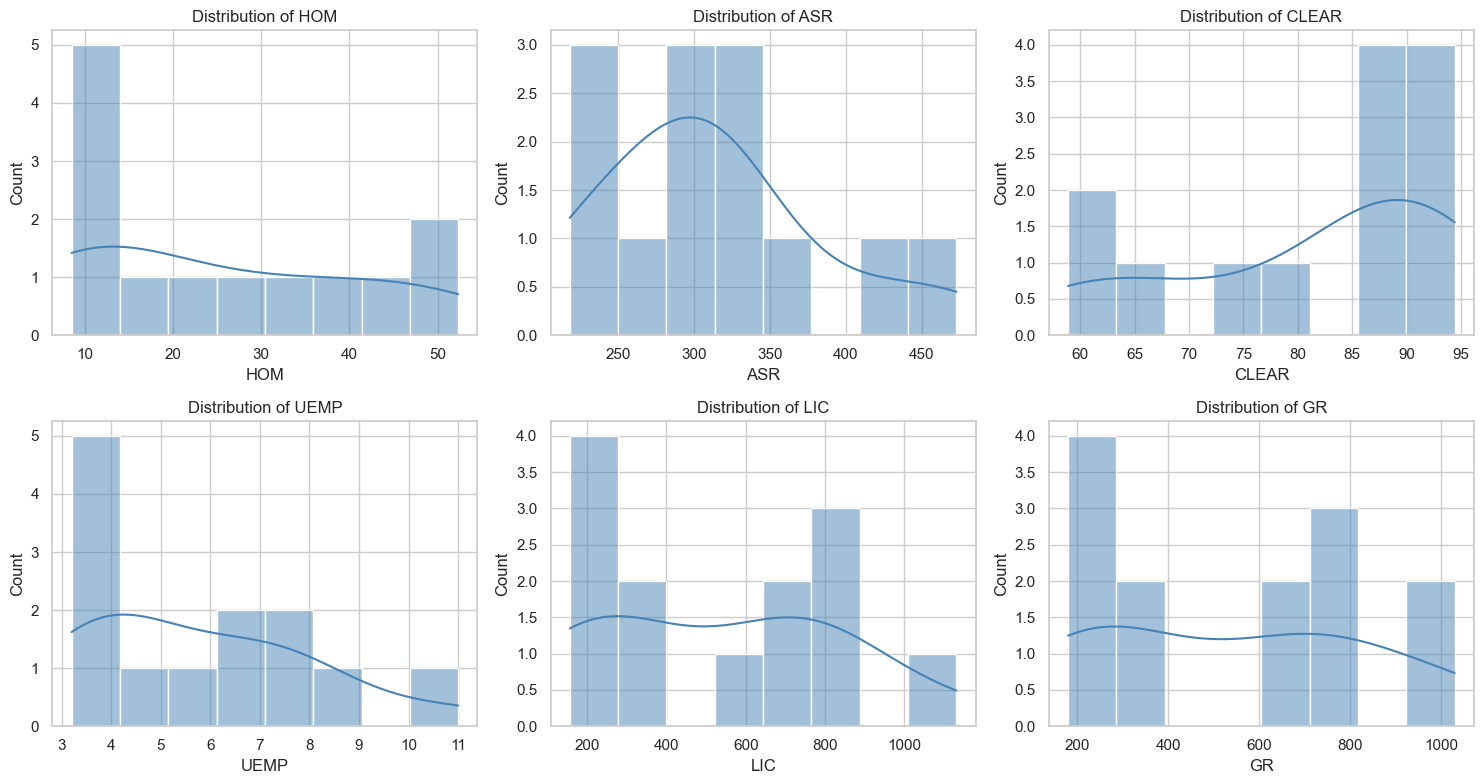

In [7]:
dist_cols = ["HOM", "ASR", "CLEAR", "UEMP", "LIC", "GR"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), dist_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=8, color="steelblue")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Interpretation:** The distributions provide a quick sense of skew and spread, but sample size is too small for strong inferential claims.

## 9. Correlation Analysis
We compute pairwise correlations and visualize them with a heatmap to identify linear co-movement, especially with the target variable HOM.

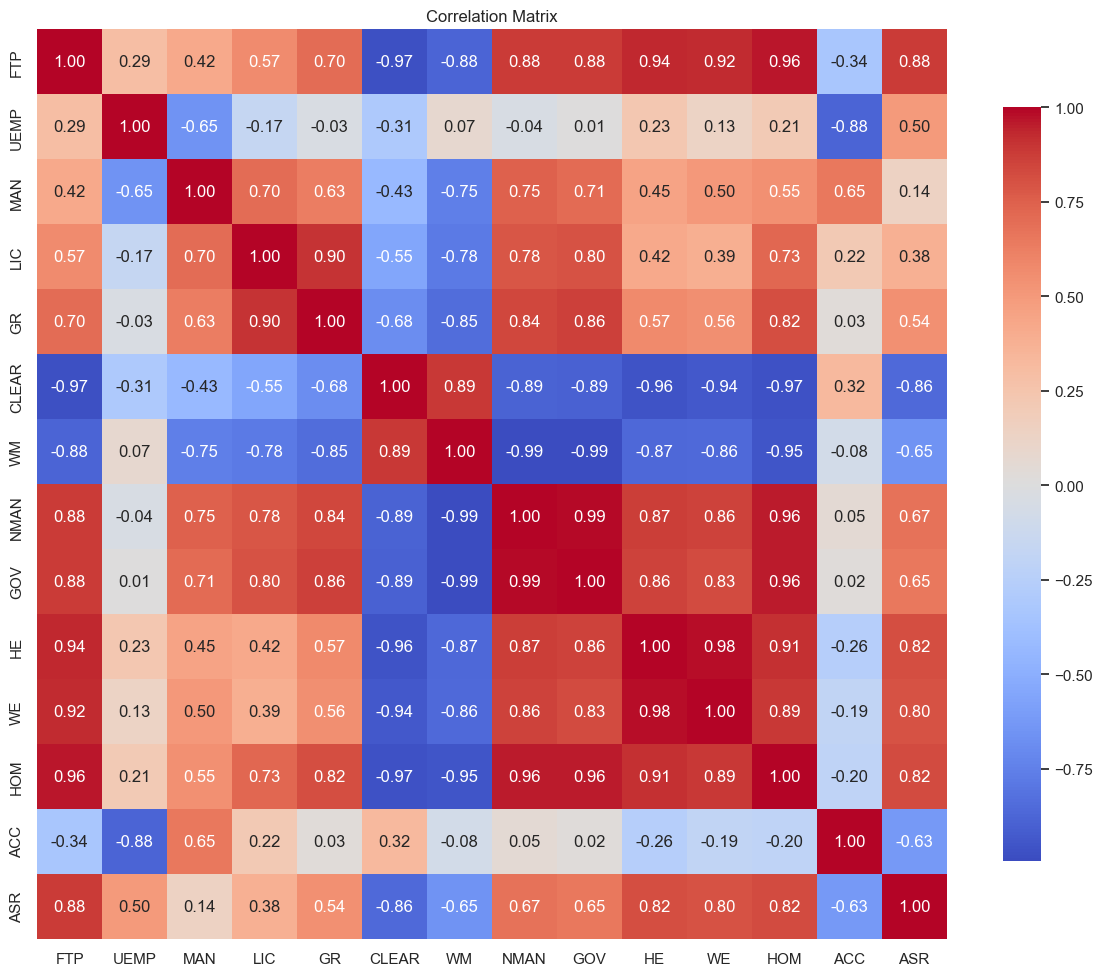

Correlations with HOM:
HOM      1.000000
FTP      0.964061
GOV      0.958055
NMAN     0.955935
HE       0.913406
WE       0.888153
ASR      0.824794
GR       0.816287
LIC      0.726305
MAN      0.546423
UEMP     0.210142
ACC     -0.204433
WM      -0.952575
CLEAR   -0.968460
Name: HOM, dtype: float64


In [8]:
corr = df.drop(columns=["Year"]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

hom_corr = corr["HOM"].sort_values(ascending=False)
print("Correlations with HOM:")
print(hom_corr)

**Interpretation:** Focus on the strongest positive and negative correlations with HOM from the printed list. These indicate association strength, not causality.

## 10. Scatterplots vs Target (HOM)
We examine bivariate relationships between HOM and selected predictors using scatterplots with fitted regression lines.

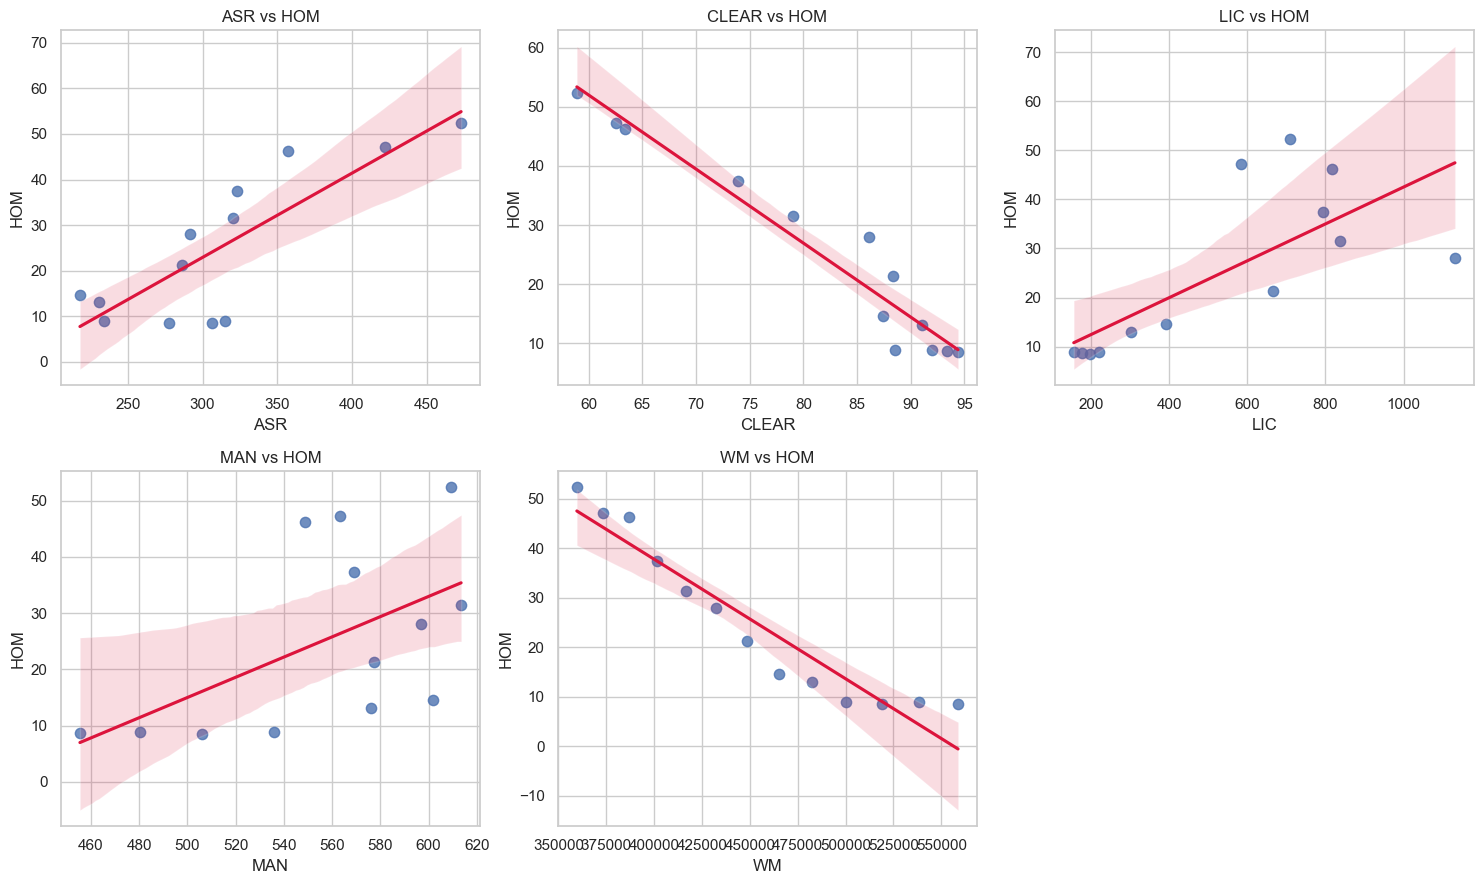

In [9]:
pairs = ["ASR", "CLEAR", "LIC", "MAN", "WM"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, var in enumerate(pairs):
    ax = axes.flatten()[i]
    sns.regplot(data=df, x=var, y="HOM", ax=ax, scatter_kws={"s": 55}, line_kws={"color": "crimson"})
    ax.set_title(f"{var} vs HOM")
    ax.set_xlabel(var)
    ax.set_ylabel("HOM")

axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

**Interpretation:** The fitted lines summarize direction and strength of association with HOM, but these patterns are descriptive and should not be interpreted as causal effects.

## 11. Socioeconomic Relationships
We explore additional pairwise relationships among socioeconomic variables to understand broader structural co-movement in the dataset.

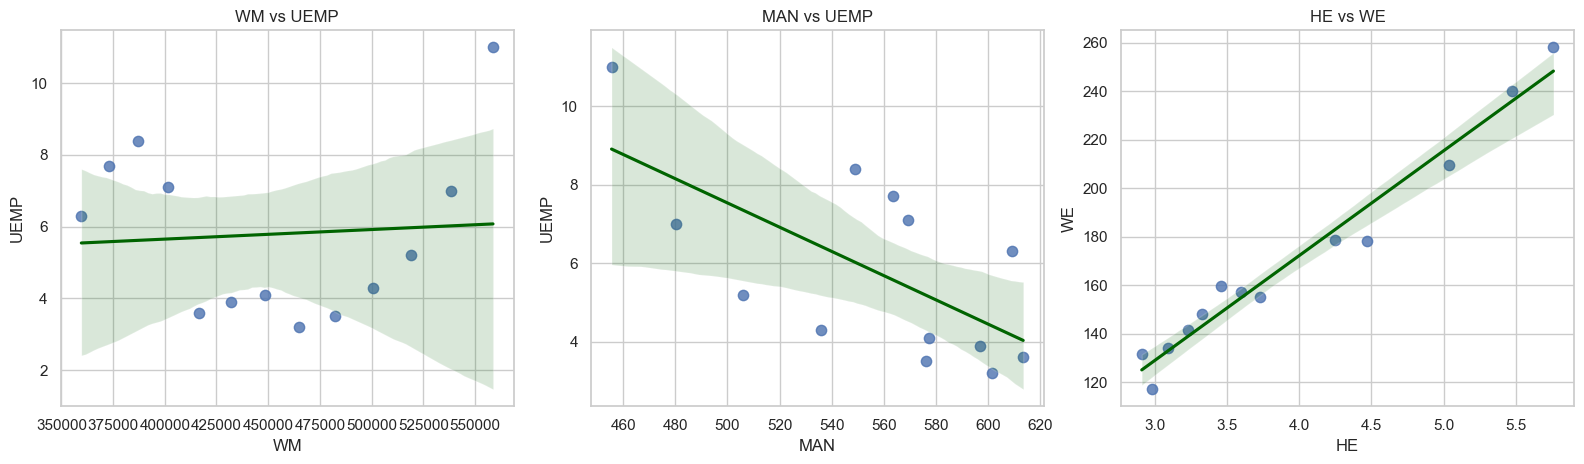

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.regplot(data=df, x="WM", y="UEMP", ax=axes[0], scatter_kws={"s": 55}, line_kws={"color": "darkgreen"})
axes[0].set_title("WM vs UEMP")
axes[0].set_xlabel("WM")
axes[0].set_ylabel("UEMP")

sns.regplot(data=df, x="MAN", y="UEMP", ax=axes[1], scatter_kws={"s": 55}, line_kws={"color": "darkgreen"})
axes[1].set_title("MAN vs UEMP")
axes[1].set_xlabel("MAN")
axes[1].set_ylabel("UEMP")

sns.regplot(data=df, x="HE", y="WE", ax=axes[2], scatter_kws={"s": 55}, line_kws={"color": "darkgreen"})
axes[2].set_title("HE vs WE")
axes[2].set_xlabel("HE")
axes[2].set_ylabel("WE")

plt.tight_layout()
plt.show()

**Interpretation:** These relationships are exploratory and help reveal co-movement among labor and earnings variables without implying directional mechanisms.

## 12. Limitations
- Small dataset: only 13 annual observations.
- Aggregated yearly data may mask within-year variation.
- Results are descriptive; no causal conclusions should be drawn.

## 13. Final Summary
- The homicide rate (HOM) generally trends upward over 1961-1973.
- Clearance rates tend to decline over time, while gun-related indicators increase.
- Manufacturing-related measures generally decline, aligning with broader structural shifts.
- Several predictors show strong pairwise correlations, indicating multicollinearity risk for regression modeling.
- Due to limited sample size and trend effects, findings should be treated as exploratory associations.